Task 1

In [ ]:
!pip install datasets lxml cairosvg sentencepiece tokenizers tqdm matplotlib
# cairosvg wasn't there so i had to do this. included the others just incase

In [ ]:
import re
import random
import matplotlib.pyplot as plt
from tqdm import tqdm
from datasets import load_dataset
from lxml import etree
import cairosvg

from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

In [ ]:
# small dataset
icons = load_dataset("starvector/svg-icons-simple", split="train")

# adding more
emoji = load_dataset("starvector/svg-emoji-simple", split="train")

# EVEN MORE (very big): using this for diversity
stack = load_dataset("starvector/svg-stack-simple", split="train[:20%]")

# if memory issues → subsample fonts
# fonts = fonts.shuffle(seed=42).select(range(100000))  # adjust size

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00015.parquet:   0%|          | 0.00/250M [00:00<?, ?B/s]

data/train-00001-of-00015.parquet:   0%|          | 0.00/247M [00:00<?, ?B/s]

data/train-00002-of-00015.parquet:   0%|          | 0.00/241M [00:00<?, ?B/s]

data/train-00003-of-00015.parquet:   0%|          | 0.00/243M [00:00<?, ?B/s]

...

data/test-00000-of-00001.parquet:   0%|          | 0.00/9.27M [00:00<?, ?B/s]

data/val-00000-of-00001.parquet:   0%|          | 0.00/181M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1229633 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3235 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/61507 [00:00<?, ? examples/s]

In [ ]:
all_data = list(icons) + list(emoji) + list(stack)
print("total raw samples:", len(all_data))

total raw samples: 330475


In [ ]:
print(len(icons))
print(icons.features)
print(icons[0])

print(len(emoji))
print(emoji.features)
print(emoji[0])

print(len(stack))
print(stack.features)
print(stack[0])

80434
{'Filename': Value('int64'), 'Svg': Value('string')}
{'Filename': 78042, 'Svg': '<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0"  filling="0" d="M10.059374809265137 7.275000095367432 L10.059374809265137 7.275000095367432 C10.977089881896973 7.366771697998047 14.58566665649414 7.627137660980225 14.384374618530273 9.36875057220459 C14.17175006866455 11.208415031433105 10.620377540588379 11.302374839782715 9.46875 11.240625381469727 C8.640908241271973 11.196237564086914 4.810017108917236 10.606165885925293 5.704833984375 8.710693359375 C6.279782772064209 7.492790699005127 8.955889701843262 7.426052093505859 10.059374809265137 7.275000095367432 L10.059374809265137 7.275000095367432"></path>\n<path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0"  filling="0" d="M10.059374809265137 9.215624809265137 L10.059374809265137 9.215624809265137 C10.72203254

In [ ]:
# SVG normalization/cleaning:
import re

def clean_svg(svg):
    # remove comments
    svg = re.sub(r'<!--.*?-->', '', svg, flags=re.DOTALL)

    # remove excessive whitespace
    svg = re.sub(r'\s+', ' ', svg).strip()

    # normalize float precision
    svg = re.sub(r'(\d+\.\d+)', lambda m: f"{float(m.group()):.1f}", svg)

    # normalize quotes
    svg = svg.replace('"', "'")

    return svg

In [ ]:
# valid XML?
from lxml import etree

def is_valid_xml(svg):
    try:
        etree.fromstring(svg.encode("utf-8"))
        return True
    except:
        return False

In [ ]:
# can it be rendered?
import cairosvg

def can_render(svg):
    try:
        cairosvg.svg2png(bytestring=svg.encode("utf-8"))
        return True
    except:
        return False

In [ ]:
# checking length
MIN_LEN = 50
MAX_LEN = 2000  # maybe play around with it
# keeping it low for now
def filter_svg(svg):
    return MIN_LEN < len(svg) < MAX_LEN

# too short can lead to trivial patterns
# too long can lead to memory expplosion while training lol

In [ ]:
# now use all those functions above to clean it
from tqdm import tqdm

cleaned_data = []

for item in tqdm(all_data):
    svg = item["Svg"] # get svg

    svg = clean_svg(svg) # clean it

    if not filter_svg(svg): # filter by length
        continue

    if not is_valid_xml(svg): # valid xml?
        continue

    if not can_render(svg): # can it be rendered?
        continue

    cleaned_data.append(svg)

print("Final dataset size:", len(cleaned_data))

100%|██████████| 330475/330475 [33:03<00:00, 166.61it/s]

Final dataset size: 220488


In [ ]:
print(len(all_data))
print(len(cleaned_data))

330475
220488


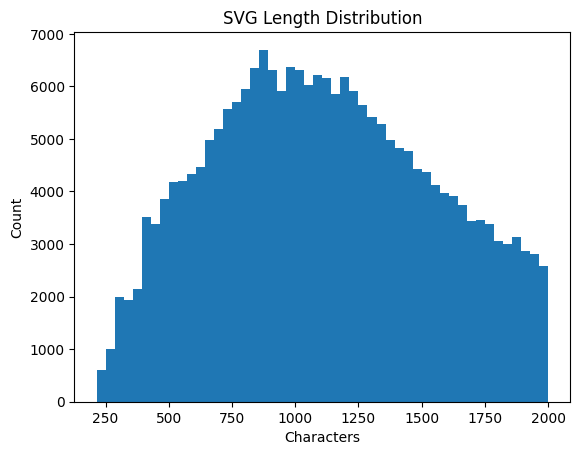

Min length: 216
Max length: 1999
Avg length: 1112.133109284859


In [ ]:
# BEFORE
lengths = [len(svg) for svg in cleaned_data]

import matplotlib.pyplot as plt

plt.hist(lengths, bins=50)
plt.title("SVG Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Count")
plt.show()

print("Min length:", min(lengths))
print("Max length:", max(lengths))
print("Avg length:", sum(lengths)/len(lengths))

In [ ]:
# train val test split
import random

random.shuffle(cleaned_data)  # shuffle

n = len(cleaned_data)

train = cleaned_data[:int(0.98 * n)]
val   = cleaned_data[int(0.98 * n):int(0.99 * n)]
test  = cleaned_data[int(0.99 * n):]

print(len(train), len(val), len(test))

216078 2205 2205


In [ ]:
from tokenizers import pre_tokenizers
# training time
tokenizer = Tokenizer(BPE())
tokenizer.pre_tokenizer = pre_tokenizers.ByteLevel()

In [ ]:
trainer = BpeTrainer(
    vocab_size=4000,
    special_tokens=["<pad>", "<unk>", "<bos>", "<eos>"]
)
# my dataset does NOT have enough unique subword patterns to support a 4k-token vocab?
# maybe bc my max tokens is at 3k?

In [ ]:
tokenizer.train_from_iterator(train, trainer)

In [ ]:
print("Vocab size:", tokenizer.get_vocab_size())

Vocab size: 4000


In [ ]:
MAX_LEN = 2048

def encode(data):
    output = []
    for svg in tqdm(data):
        ids = tokenizer.encode(svg).ids

        if len(ids) <= MAX_LEN:
            output.append(ids)

    return output

train_tokens = encode(train)
val_tokens   = encode(val)
test_tokens  = encode(test)

100%|██████████| 2205/2205 [00:09<00:00, 230.40it/s]


In [ ]:
train_lens = [len(x) for x in train_tokens]
val_lens   = [len(x) for x in val_tokens]
test_lens  = [len(x) for x in test_tokens]

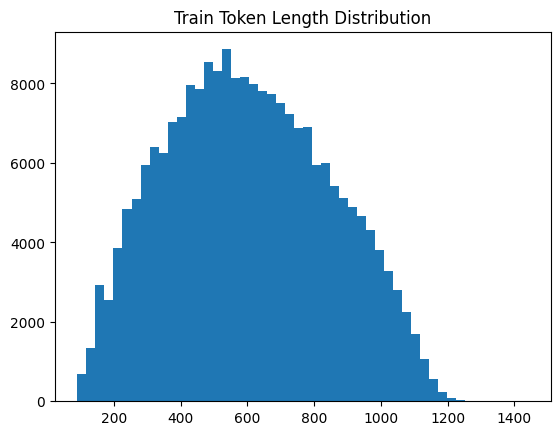

In [ ]:
plt.hist(train_lens, bins=50)
plt.title("Train Token Length Distribution")
plt.show()

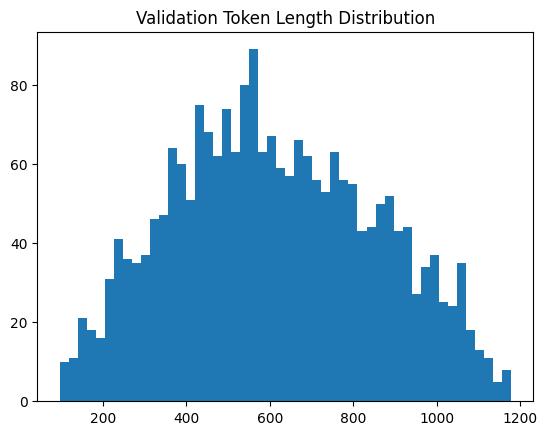

In [ ]:
plt.hist(val_lens, bins=50)
plt.title("Validation Token Length Distribution")
plt.show()

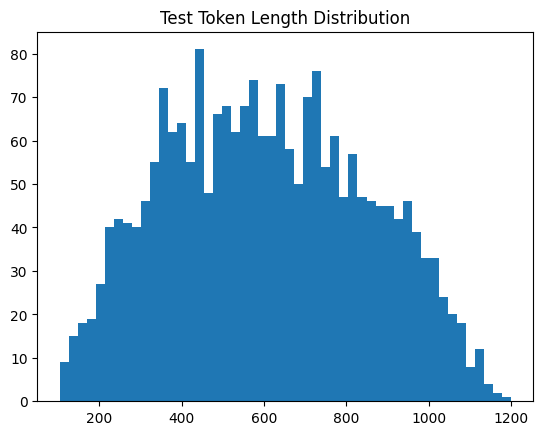

In [ ]:
plt.hist(test_lens, bins=50)
plt.title("Test Token Length Distribution")
plt.show()

In [ ]:
print("Avg train tokens:", sum(train_lens)/len(train_lens))
print("Avg val tokens:", sum(val_lens)/len(val_lens))
print("Avg test tokens:", sum(test_lens)/len(test_lens))

Avg train tokens: 603.1869972880164
Avg val tokens: 612.1206349206349
Avg test tokens: 606.1646258503401


In [ ]:
train_total = sum(train_lens) # is this > 100M
val_total   = sum(val_lens)
test_total  = sum(test_lens)

print("Train tokens:", train_total)
print("Val tokens:", val_total)
print("Test tokens:", test_total)

print("TOTAL TOKENS:", train_total + val_total + test_total)

Train tokens: 130335440
Val tokens: 1349726
Test tokens: 1336593
TOTAL TOKENS: 133021759


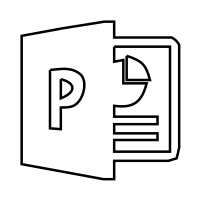

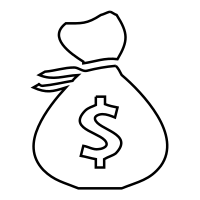

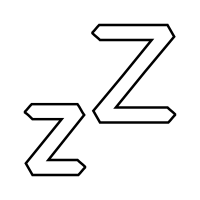

In [ ]:
# render them
from IPython.display import SVG, display

for i in range(3):
    display(SVG(train[i]))

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
base_path = "/content/drive/MyDrive/Colab Notebooks/ML"

In [ ]:
tokenizer.save(base_path + "/svg_tokenizer.json")

In [ ]:
import torch

torch.save(train_tokens, base_path + "/train_tokens.pt")
torch.save(val_tokens, base_path + "/val_tokens.pt")
torch.save(test_tokens, base_path + "/test_tokens.pt")

In [ ]:
import json

metadata = {
    "vocab_size": tokenizer.get_vocab_size(),
    "train_samples": len(train_tokens),
    "val_samples": len(val_tokens),
    "test_samples": len(test_tokens),
    "train_tokens": sum(len(x) for x in train_tokens),
    "val_tokens": sum(len(x) for x in val_tokens),
    "test_tokens": sum(len(x) for x in test_tokens),
    "max_len": 2048
}

with open(base_path + "/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

In [ ]:
!ls "/content/drive/MyDrive/Colab Notebooks/ML"

metadata.json	   svg_tokenizer.json  train_tokens.pt
MLprojPart2.ipynb  test_tokens.pt      val_tokens.pt


In [ ]:

print(tokenizer.get_vocab_size())

4000
